In [16]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

LIMIT = 2000

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
                # "tags": {"$in": ["aug"]},
    },
    order="-created_at",
    per_page=LIMIT,
    # limit to 10:
    lazy=False
)

In [54]:
rows = []
for run in runs:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "train_accuracy": summary.get("train_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
        'tags': attrs.get("tags", []),
        'input_dim': params.get("input_dim"),
        'feature_subset': params.get('feature_subset', params.get('midterm_feature_subset')),
        'eval_only': params.get("eval_only"),
        'graph': params.get('root', 'nan') + '/' + params.get('graph_filename', 'nan')
    })
df = pd.DataFrame(rows)
df["task_name"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df['created_at'] = pd.to_datetime(df['created_at'])
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df['trained_on_display_name'] = df.pretrained_model_run.str.findall("(.+)/(.+)/((checkpoint/(.+)\.ckpt)|state_dict)$").str[0].str[1]
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
mask = df['trained_on_display_name'].isin(df['display_name'])
existing_trained_on_display_names = df.trained_on_display_name[mask]
df__ = df.copy()

df['shots'] = pd.to_numeric(df.n_shots.fillna(-1)).astype(int)

df = df[df.dataset.isin(['midterm', 'ukr_rus_twitter', 'covid19_twitter', 'covid_political', 'ukr_rus_suspended', 'election2020'])]
df = df[df.pretrained_model_run.notna()]
df = df[~df.display_name.str.contains('train3')]
df = df[~df.display_name.str.contains('eval_exp')]

df["train_tuples"] = None  # or use pd.Series(dtype=object)
df["run_list"] = None  # or use pd.Series(dtype=object)

for i, row in list(df.iterrows()):
    train_list = []
    run_list = []
    row_ = row.copy()
    # print(row_.display_name)

    while pd.notna(row_.trained_on_display_name):
        # print("->", row_.trained_on_display_name)
        matches = df[df.display_name.eq(row_.trained_on_display_name)]
        if len(matches) != 1:
            print('warn:', row_.trained_on_display_name, )
            break
        row_ = matches.iloc[0]
        train_list.append((row_["dataset"], row_["task_name"], row_.get('shots', -1)))
        run_list.append(row_.run_id)

    # print('\t', train_list)
    df.at[i, "train_tuples"] = train_list
    df.at[i, "run_list"] = run_list


# x = df.train_idx.explode().dropna().groupby(level=0).agg(list)
# df['train_idx'] = np.nan
# df['train_idx'] = x
df = df[~df.display_name.str.contains('train\d*_')]

df['train_id'] = df.train_tuples.apply(lambda x: [f'{d}+{t}({s})' for (d,t,s) in x]).apply('>'.join).replace({'':np.nan})
df['eval_only'] = df['eval_only'].fillna(False)
df.loc[df.eval_only, 'eval_dataset'] = df['dataset']
df.loc[df.eval_only, 'eval_task'] = df['task_name']
df.loc[df.eval_only, 'eval_id'] = df.eval_dataset + "+" + df.eval_task + "(" + df.shots.astype(str) + ")"
df.loc[df.eval_only, 'run_idx'] = df.run_list.apply('>'.join).replace('', 'nan') + "|" + df.eval_id
df['seq'] = df.train_id + "|" + df.eval_id

df['auc'] = df.test_roc_auc
df['f1'] = df.test_f1
# df = df[df.created_at.gt('03-01-2026')]
# df = df.drop_duplicates(['seq', ''])
# df = df[df.feature_subset.eq('emb_only')]
# df = df[df.display_name.str[:10].isin(['trained_on', 'eval_covid', 'eval_midte', 'eval_ukr_r', 'eval_nm_on', 'eval_pl_on', 'eval_lp_on'])]

graphs = ["/scratch1/eibl/data/covid_political/graphs/retweet_graph.pt",
"/scratch1/eibl/data/election2020/graphs/retweet_graph.pt",
"/scratch1/eibl/data/ukr_rus_suspended/graphs/retweet_graph.pt",
"/scratch1/eibl/data/covid19_twitter/graphs/retweet_graph_1p5m_hf03_labeled.pt",
"/scratch1/eibl/data/ukr_rus_twitter/graphs/retweet_graph_1p5m_hf03_political_labels.pt",
"/scratch1/eibl/data/midterm/graphs/retweet_graph_1p5m.pt",]

df = df[df.graph.isin(graphs)]

df = df.dropna(subset=['auc'])

df['train_id_'] = df.train_id.str.replace('\(\d+\)', '', regex=True)
df['eval_id_'] = df.eval_id.str.replace('\(\d+\)', '', regex=True)
df['seq_'] = df.seq.str.replace('\(\d+\)', '', regex=True)

# df.to_csv('./train1/train1.csv', index=False)

warn: pretrain_midterm_nm_test
warn: pretrain_midterm_nm_test


In [61]:
df.eval_id_.value_counts().index

Index(['covid_political+pl', 'covid_political+nm', 'ukr_rus_suspended+pl',
       'ukr_rus_suspended+nm', 'election2020+nm', 'election2020+pl',
       'covid19_twitter+pl', 'covid19_twitter+lp', 'covid19_twitter+nm',
       'midterm+pl', 'midterm+lp', 'midterm+nm', 'ukr_rus_twitter+pl',
       'ukr_rus_twitter+lp', 'ukr_rus_twitter+nm'],
      dtype='str', name='eval_id_')

In [62]:
df[df.eval_id_.eq('midterm+nm')][['trained_on_display_name', 'train_id', 'dataset', 'task_name', 'shots', 'auc', 'seq_']]


,trained_on_display_name,train_id,dataset,task_name,shots,auc,seq_
13,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),midterm,nm,10,0.982118,midterm+nm|midterm+nm
20,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),midterm,nm,3,0.977669,midterm+nm|midterm+nm
23,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),midterm,nm,0,0.501234,midterm+nm|midterm+nm
943,train1_midterm_pl_1p5m_13_04_2026_17_14_38,midterm+pl(4),midterm,nm,10,0.773122,midterm+pl|midterm+nm
953,train1_covid19_twitter_pl_1p5m_13_04_2026_11_4...,covid19_twitter+pl(4),midterm,nm,10,0.520770,covid19_twitter+pl|midterm+nm
954,train1_ukr_rus_twitter_pl_1p5m_13_04_2026_11_3...,ukr_rus_twitter+pl(4),midterm,nm,10,0.650498,ukr_rus_twitter+pl|midterm+nm
962,train1_midterm_pl_1p5m_13_04_2026_17_14_38,midterm+pl(4),midterm,nm,3,0.754305,midterm+pl|midterm+nm
975,train1_covid19_twitter_pl_1p5m_13_04_2026_11_4...,covid19_twitter+pl(4),midterm,nm,3,0.508551,covid19_twitter+pl|midterm+nm
976,train1_ukr_rus_twitter_pl_1p5m_13_04_2026_11_3...,ukr_rus_twitter+pl(4),midterm,nm,3,0.623280,ukr_rus_twitter+pl|midterm+nm
980,train1_midterm_pl_1p5m_13_04_2026_17_14_38,midterm+pl(4),midterm,nm,1,0.727707,midterm+pl|midterm+nm


In [20]:
df[df.tags.astype(str).str.contains('aug')][['trained_on_display_name', 'train_id', 'dataset', 'task_name', 'shots', 'auc']]

,trained_on_display_name,train_id,dataset,task_name,shots,auc
0,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),ukr_rus_suspended,pl,10,0.502266
1,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),covid19_twitter,pl,10,0.573293
2,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),ukr_rus_suspended,nm,10,0.780159
3,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),covid19_twitter,lp,10,0.786954
4,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),ukr_rus_suspended,pl,3,0.503729
5,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),covid19_twitter,nm,10,0.988942
6,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),midterm,pl,10,0.939505
7,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),ukr_rus_suspended,nm,3,0.743710
8,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),covid19_twitter,pl,3,0.543267
9,train1_midterm_nm_aug_03_05_2026_20_36_07,midterm+nm(3),ukr_rus_suspended,pl,0,0.512756


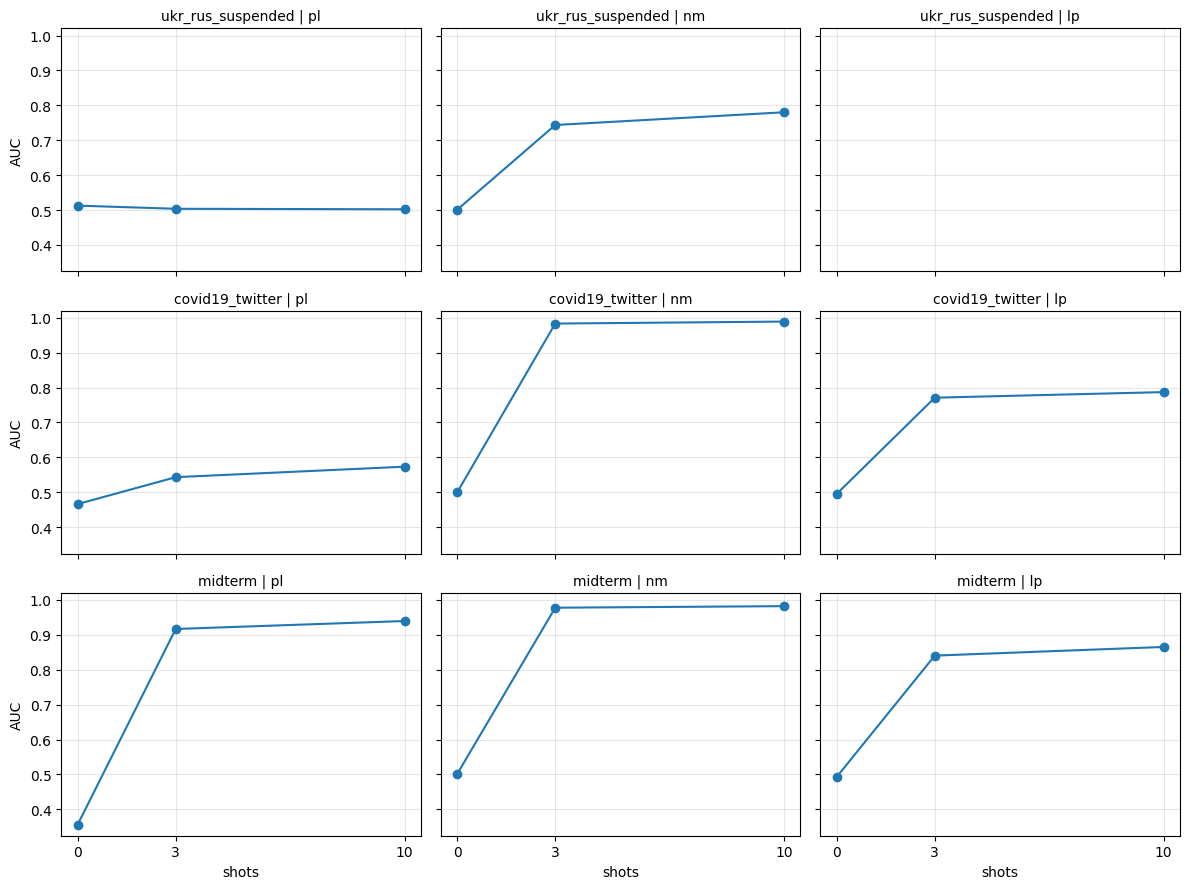

In [14]:
import matplotlib.pyplot as plt

datasets = df['dataset'].unique()
tasks = df['task_name'].unique()

fig, axes = plt.subplots(
    len(datasets), len(tasks),
    figsize=(4 * len(tasks), 3 * len(datasets)),
    sharex=True, sharey=True
)

for i, dataset in enumerate(datasets):
    for j, task in enumerate(tasks):
        ax = axes[i, j]
        s = df[(df['dataset'] == dataset) & (df['task_name'] == task)].sort_values('shots')
        if len(s):
            ax.plot(s['shots'], s['auc'], marker='o')
        ax.set_title(f'{dataset} | {task}', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(df['shots'].unique()))
        if i == len(datasets) - 1:
            ax.set_xlabel('shots')
        if j == 0:
            ax.set_ylabel('AUC')

plt.tight_layout()
plt.show()

In [122]:
df[df.train_id_.str.contains('midterm\+nm')].eval_id.unique()

<ArrowStringArray>
['ukr_rus_suspended+pl(10)',   'covid19_twitter+pl(10)',
 'ukr_rus_suspended+nm(10)',   'covid19_twitter+lp(10)',
  'ukr_rus_suspended+pl(3)',   'covid19_twitter+nm(10)',
           'midterm+pl(10)',  'ukr_rus_suspended+nm(3)',
    'covid19_twitter+pl(3)',  'ukr_rus_suspended+pl(0)',
           'midterm+lp(10)',    'covid19_twitter+lp(3)',
    'covid19_twitter+nm(3)',           'midterm+nm(10)',
  'ukr_rus_suspended+nm(0)',    'covid19_twitter+pl(0)',
            'midterm+pl(3)',    'covid19_twitter+lp(0)',
            'midterm+lp(3)',    'covid19_twitter+nm(0)',
            'midterm+nm(3)',            'midterm+pl(0)',
            'midterm+lp(0)',            'midterm+nm(0)',
      'election2020+pl(10)',      'election2020+nm(10)',
       'election2020+pl(1)',   'covid_political+pl(10)',
       'election2020+nm(1)',       'election2020+pl(0)',
   'covid_political+nm(10)',    'covid_political+pl(1)',
  'ukr_rus_suspended+pl(1)',    'covid_political+nm(1)',
  'ukr_rus_s

In [127]:
x = df[df.train_id_.str.contains('midterm\+nm')].eval_id.unique()
c = []
for eid in df[df.tags.astype(str).str.contains('aug')].eval_id_.unique():
    x = df[df.seq_.eq(eid + "|" + eid)]
    c += [x]
    y = df[df.train_id_.eq('midterm+nm') & df.eval_id_.eq(eid)]
    c += [y]
c = pd.concat(c)
c = pd.concat([c, x])
# y = df[df.seq_id.eq()]

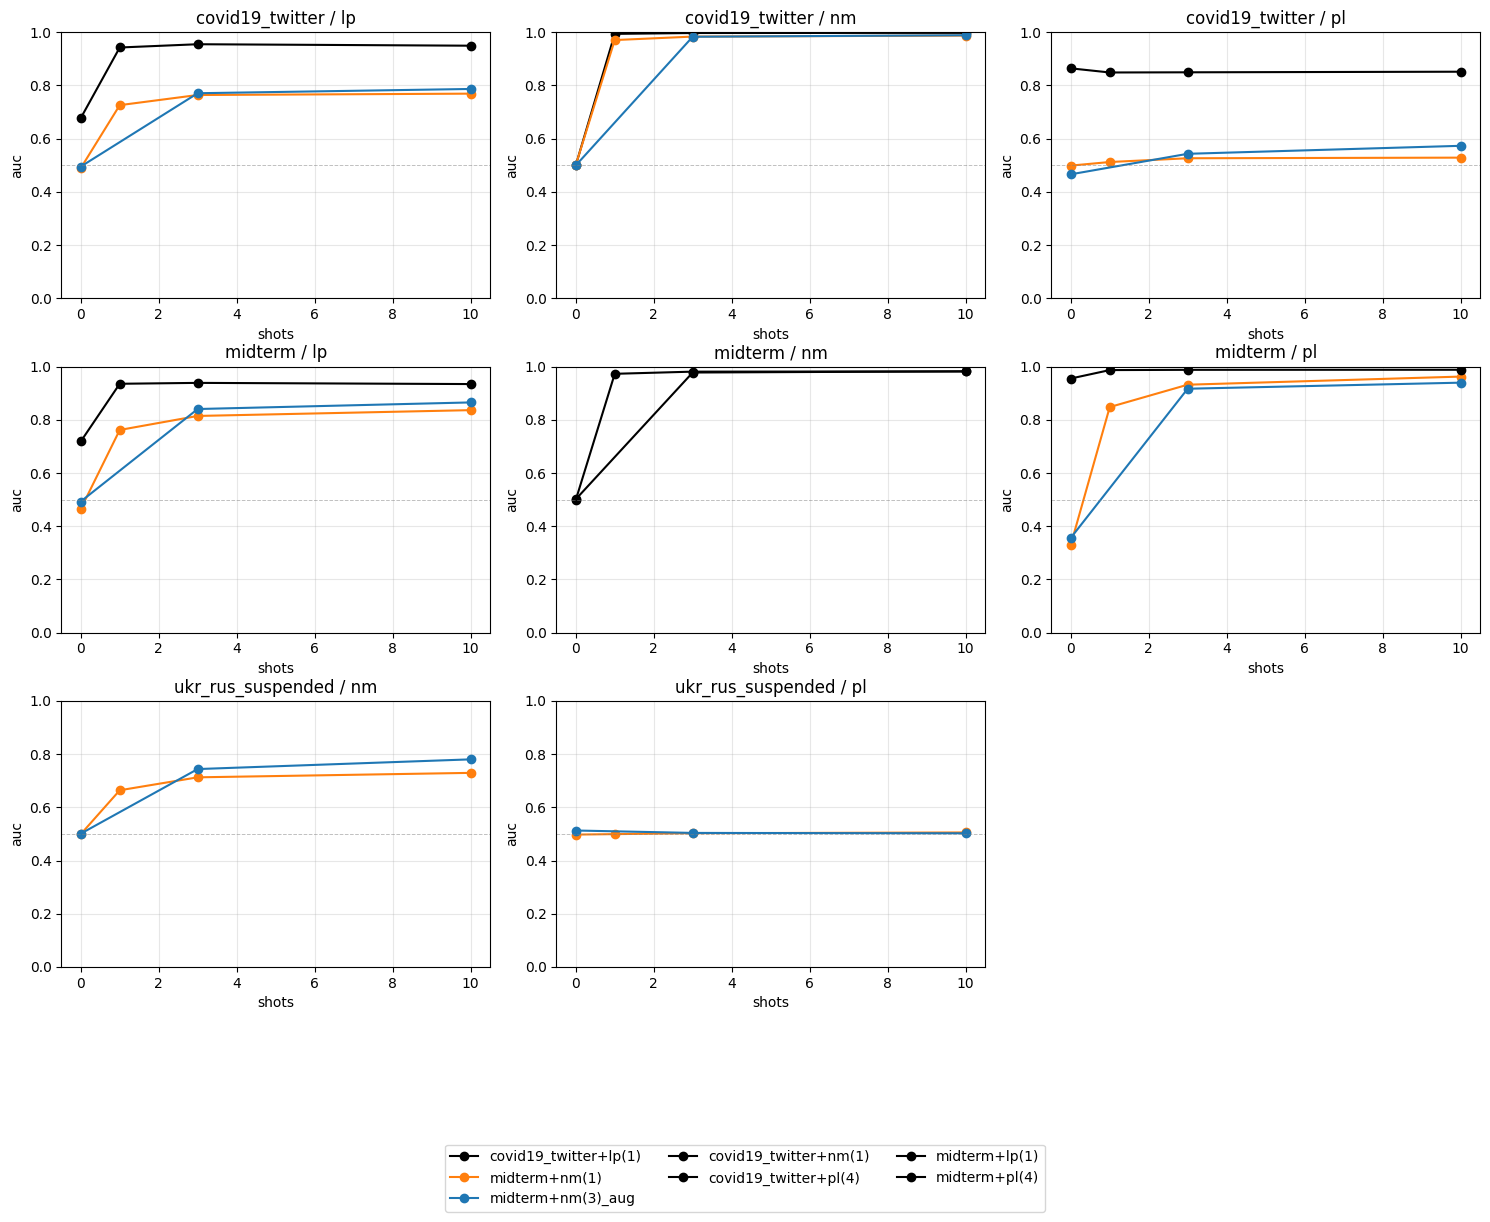

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

groups = c.groupby(['dataset', 'task_name'])
n = len(groups)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes = axes.flatten()

train_ids = c['train_id'].unique()
palette = dict(zip(train_ids, sns.color_palette('tab10', len(train_ids))))

def label_for(tid, sub):
    tags = sub.loc[sub['train_id'] == tid, 'tags'].iloc[0]
    is_aug = isinstance(tags, (list, tuple)) and 'aug' in tags
    return f"{tid}_aug" if is_aug else str(tid)

for ax, ((dataset, task), g) in zip(axes, groups):
    for tid, gg in g.groupby('train_id'):
        gg = gg.sort_values('shots')
        gg = gg.groupby('shots', as_index=False)['auc'].mean()
        same = (tid.split('(')[0] == dataset + "+" + task)     # <-- match check
        # print(tid.split('(')[0], dataset + "+" + task)
        color = 'black' if same else palette[tid]
        ax.plot(gg['shots'], gg['auc'], marker='o',
                color=color,
                label=label_for(tid, g))
    ax.set_title(f'{dataset} / {task}')
    ax.set_xlabel('shots')
    ax.set_ylabel('auc')
    ax.set_ylim((0, 1))
    ax.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)
    ax.grid(alpha=0.3)

for ax in axes[n:]:
    ax.set_visible(False)

seen = {}
for ax in axes[:n]:
    for h, l in zip(*ax.get_legend_handles_labels()):
        seen.setdefault(l, h)

fig.legend(seen.values(), seen.keys(), loc='lower center',
           ncol=min(len(seen), 3), bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.subplots_adjust(bottom=0.1 + 0.03*((len(seen)+2)//3))
plt.show()

In [162]:
aug_mask = df.tags.astype(str).str.contains('aug')
a = df[aug_mask & df.shots.eq(3)]
a['aug'] = True
b = df[df.seq.str.contains('midterm\+nm.\d+.\|(ukr_rus_suspended|midterm|covid19_twitter)\+...3.') & ~aug_mask]
b['aug'] = False

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74645/2286588189.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  b = df[df.seq.str.contains('midterm\+nm.\d+.\|(ukr_rus_suspended|midterm|covid19_twitter)\+...3.') & ~aug_mask]


In [186]:
c.groupby(['seq_']).apply(lambda x: x[x.aug.eq(True)].auc.values[0] - x[x.aug.eq(False)].auc.values[0]).mean()

0.00783391002314815

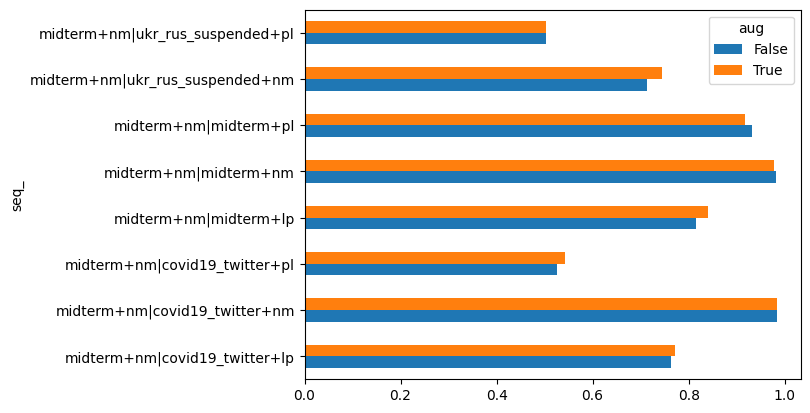

In [173]:
import matplotlib.pyplot as plt

c = pd.concat([a, b])
c = c.sort_values('seq_')

pivot = c.pivot(index='seq_', columns='aug', values='auc')
pivot.plot.barh()
plt.show()